# Abertura do Dataset

In [1]:
# Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_1 = pd.read_csv("medals_total.csv")
df_2 = pd.read_csv("world_olympedia_olympics_game_medal_tally.csv")

In [3]:
# Visualização Inicial
df_1.head()

,country_code,country,country_long,Gold Medal,Silver Medal,Bronze Medal,Total
0,USA,United States,United States of America,40,44,42,126
1,CHN,China,People's Republic of China,40,27,24,91
2,JPN,Japan,Japan,20,12,13,45
3,AUS,Australia,Australia,18,19,16,53
4,FRA,France,France,16,26,22,64


In [4]:
df_2.head()

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1896,1896 Summer Olympics,1,Greece,GRE,10,18,19,47
1,1900,1900 Summer Olympics,2,France,FRA,31,41,40,112
2,1900,1900 Summer Olympics,2,United States,USA,20,13,15,48
3,1904,1904 Summer Olympics,3,United States,USA,80,85,83,248
4,1908,1908 Summer Olympics,5,Great Britain,GBR,56,51,39,146


In [5]:
print("Países da Base 1 (2024) : ", df_1['country'].sort_values().unique())
print("Países da Base 2 (1896-2022) : ", df_2['country'].sort_values().unique())

Países da Base 1 (2024) :  ['AIN' 'Albania' 'Algeria' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahrain' 'Belgium' 'Botswana' 'Brazil' 'Bulgaria'
 'Cabo Verde' 'Canada' 'Chile' 'China' 'Chinese Taipei' 'Colombia'
 'Croatia' 'Cuba' 'Cyprus' 'Czechia' "Côte d'Ivoire" 'DPR Korea' 'Denmark'
 'Dominica' 'Dominican Republic' 'EOR' 'Ecuador' 'Egypt' 'Ethiopia' 'Fiji'
 'France' 'Georgia' 'Germany' 'Great Britain' 'Greece' 'Grenada'
 'Guatemala' 'Hong Kong, China' 'Hungary' 'IR Iran' 'India' 'Indonesia'
 'Ireland' 'Israel' 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan'
 'Kenya' 'Korea' 'Kosovo' 'Kyrgyzstan' 'Lithuania' 'Malaysia' 'Mexico'
 'Mongolia' 'Morocco' 'Netherlands' 'New Zealand' 'Norway' 'Pakistan'
 'Panama' 'Peru' 'Philippines' 'Poland' 'Portugal' 'Puerto Rico' 'Qatar'
 'Republic of Moldova' 'Romania' 'Saint Lucia' 'Serbia' 'Singapore'
 'Slovakia' 'Slovenia' 'South Africa' 'Spain' 'Sweden' 'Switzerland'
 'Tajikistan' 'Thailand' 'Tunisia' 'Türkiye' 'Uganda' 'Ukraine'


In [6]:
print(df_1.info())
print(df_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_code  92 non-null     object
 1   country       92 non-null     object
 2   country_long  92 non-null     object
 3   Gold Medal    92 non-null     int64 
 4   Silver Medal  92 non-null     int64 
 5   Bronze Medal  92 non-null     int64 
 6   Total         92 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 5.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807 entries, 0 to 1806
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   year         1807 non-null   int64 
 1   edition      1807 non-null   object
 2   edition_id   1807 non-null   int64 
 3   country      1807 non-null   object
 4   country_noc  1807 non-null   object
 5   gold         1807 non-null   int64 
 6   silver       1807 non-null

# Parte 1 - Consolidação de Medalhas por País

## Pré-processamento

- Padronizar as bases de dados
  - Nomes dos países
  - Nome e Ordem das Colunas
- Separação do registro da Alemanha na 2º base
- Concatenar as duas bases

In [7]:
# BASE DE DADOS 1

# Padronizando nomes dos países
country_map_1 = {
    'IR Iran': 'Iran',
    'Korea': 'Republic of Korea'
}
df_1['country'] = df_1['country'].replace(country_map_1)

# Padronizando nomes das colunas
df_1['year'] = 2024
df_1['edition'] = 'Summer Olympics'
df_1['edition_id'] = 63
df_1.rename(columns={
    "country_code": "country_noc",
    "Gold Medal": "gold",
    "Silver Medal": "silver",
    "Bronze Medal": "bronze",
    "Total": "total"
    }, inplace=True)

# Removendo colunas que não serão usadas
df_1 = df_1.drop(columns={"country_long"})

# Reordenando as colunas
df_1 = df_1.reindex(columns=[
    'year', 'edition', 'edition_id', 'country',
    'country_noc', 'gold', 'silver', 'bronze', 'total'])

# Verificando resultado
df_1.head()

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,2024,Summer Olympics,63,United States,USA,40,44,42,126
1,2024,Summer Olympics,63,China,CHN,40,27,24,91
2,2024,Summer Olympics,63,Japan,JPN,20,12,13,45
3,2024,Summer Olympics,63,Australia,AUS,18,19,16,53
4,2024,Summer Olympics,63,France,FRA,16,26,22,64


In [8]:
# BASE DE DADOS 2

# Padronizando nomes dos países
country_map_2 = {
    "People's Republic of China": 'China',
    "Democratic People's Republic of Korea": 'DPR Korea',
    "Islamic Republic of Iran": 'Iran',
}

df_2['country'] = df_2['country'].replace(country_map_2)

# Separando a coluna 'edition' para "Summer Olympics" e "Winter Olympics"
df_2['edition'] = df_2['edition'].str.replace(r'\d+\s', '', regex=True)

# Verificando resultado
df_2.head()

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1896,Summer Olympics,1,Greece,GRE,10,18,19,47
1,1900,Summer Olympics,2,France,FRA,31,41,40,112
2,1900,Summer Olympics,2,United States,USA,20,13,15,48
3,1904,Summer Olympics,3,United States,USA,80,85,83,248
4,1908,Summer Olympics,5,Great Britain,GBR,56,51,39,146


In [9]:
# Identificando os registros da alemanha enquanto Equipe Alemã Unida
df_2[
    (df_2['country'] == "Germany") &
     (df_2['year'].isin([1956, 1960, 1964]))
    ].reset_index(drop=True)


,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1964,Summer Olympics,16,Germany,GER,10,22,18,50
1,1956,Equestrian,48,Germany,GER,2,3,1,6
2,1956,Winter Olympics,35,Germany,GER,1,0,1,2
3,1960,Winter Olympics,36,Germany,GER,4,3,1,8
4,1964,Winter Olympics,37,Germany,GER,3,3,3,9
5,1956,Summer Olympics,14,Germany,GER,4,10,6,20
6,1960,Summer Olympics,15,Germany,GER,12,19,11,42


In [10]:
# Identificando e alterando os registros da Alemanha enquanto Equipe Alemã Unida
df_2.loc[
    (df_2['country'] == "Germany") & (df_2['year'].isin([1956, 1960, 1964])),
    'country'
] = 'UT Germany'

# Verificando resultado
df_2[df_2["country"] == "UT Germany"].groupby("year").size()

,0
year,
1956,3
1960,2
1964,2


In [11]:
# Fazendo a concatenação das bases de dados
df_final = pd.concat([df_2, df_1])

# Verificando resultado
df_final

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1896,Summer Olympics,1,Greece,GRE,10,18,19,47
1,1900,Summer Olympics,2,France,FRA,31,41,40,112
2,1900,Summer Olympics,2,United States,USA,20,13,15,48
3,1904,Summer Olympics,3,United States,USA,80,85,83,248
4,1908,Summer Olympics,5,Great Britain,GBR,56,51,39,146
...,...,...,...,...,...,...,...,...,...
87,2024,Summer Olympics,63,Peru,PER,0,0,1,1
88,2024,Summer Olympics,63,Qatar,QAT,0,0,1,1
89,2024,Summer Olympics,63,Singapore,SGP,0,0,1,1
90,2024,Summer Olympics,63,Slovakia,SVK,0,0,1,1


## Agrupamento dos Dados
- Jogos de Verão
- Jogos de Inverno
- Total

## Medalhas - Jogos de Verão

In [21]:
# Tabela dos Jogos de Verão
df_summer = df_final[df_final['edition'] == 'Summer Olympics']

# Total de Medalhas nos Jogos de Verão por País
df_summer_total = (
    df_summer.groupby('country')[['gold', 'silver', 'bronze', 'total']]
    .sum()
    .sort_values("total", ascending=False)
)

df_summer_total

,gold,silver,bronze,total
country,,,,
United States,1110,885,786,2781
Soviet Union,395,319,296,1010
Great Britain,305,345,342,992
France,247,283,307,837
China,303,226,198,727
...,...,...,...,...
Sudan,0,1,0,1
Turkmenistan,0,1,0,1
Togo,0,0,1,1


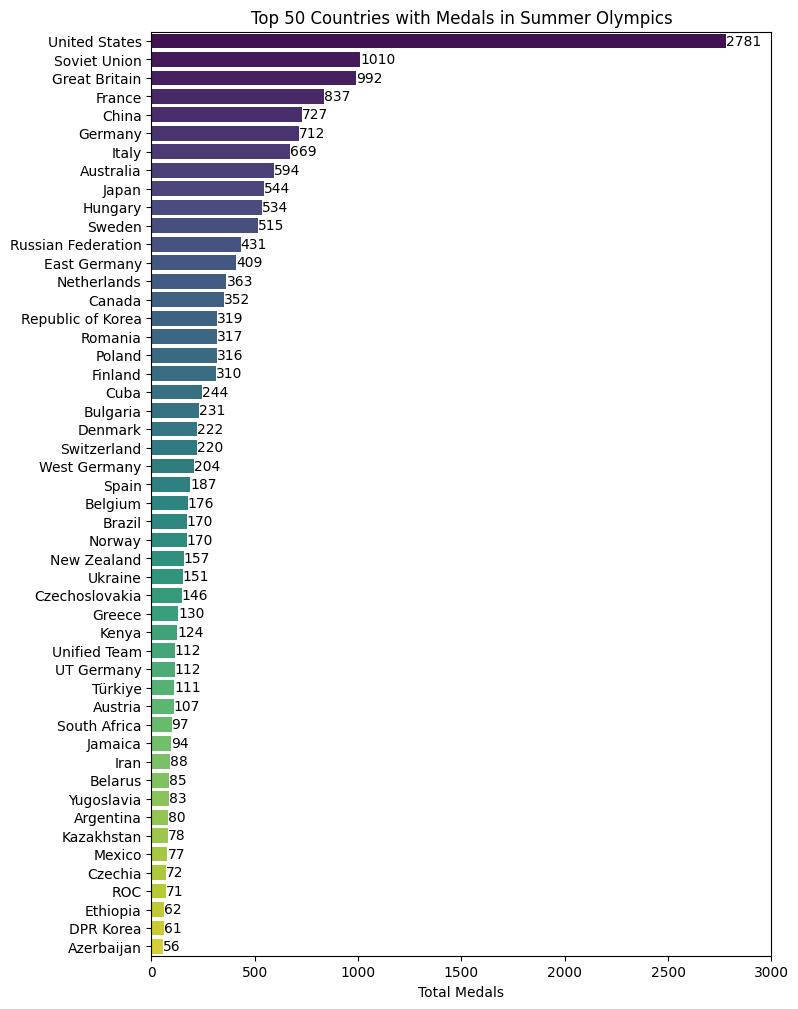

In [26]:
# Top 50 países das Olimpiadas Verão
plt.figure(figsize=(8, 12))

ax = sns.barplot(x=df_summer_total.head(50)['total'],
            y=df_summer_total.head(50).index,
            orient='h',
            hue=df_summer_total.head(50).index,
            palette='viridis'
            )

for i in range(len(ax.containers)):
  ax.bar_label(ax.containers[i], color='black')

ax.set_xlabel('Total Medals')
ax.set_xlim(0, 3000)
ax.set_ylabel("")

ax.set_title('Top 50 Countries with Medals in Summer Olympics')

plt.show()

## Medalhas - Jogos de Inverno

In [23]:
# Tabela dos Jogos de Inverno
df_winter = df_final[df_final['edition'] == 'Winter Olympics']

df_winter_total = (
    df_winter.groupby('country')[['gold', 'silver', 'bronze', 'total']]
    .sum()
    .sort_values('total', ascending=False))

df_winter_total

,gold,silver,bronze,total
country,,,,
Norway,148,134,123,405
United States,113,122,95,330
Germany,104,98,65,267
Austria,71,88,91,250
Canada,77,72,76,225
Soviet Union,78,57,59,194
Sweden,65,51,60,176
Finland,45,65,65,175
Switzerland,63,47,58,168


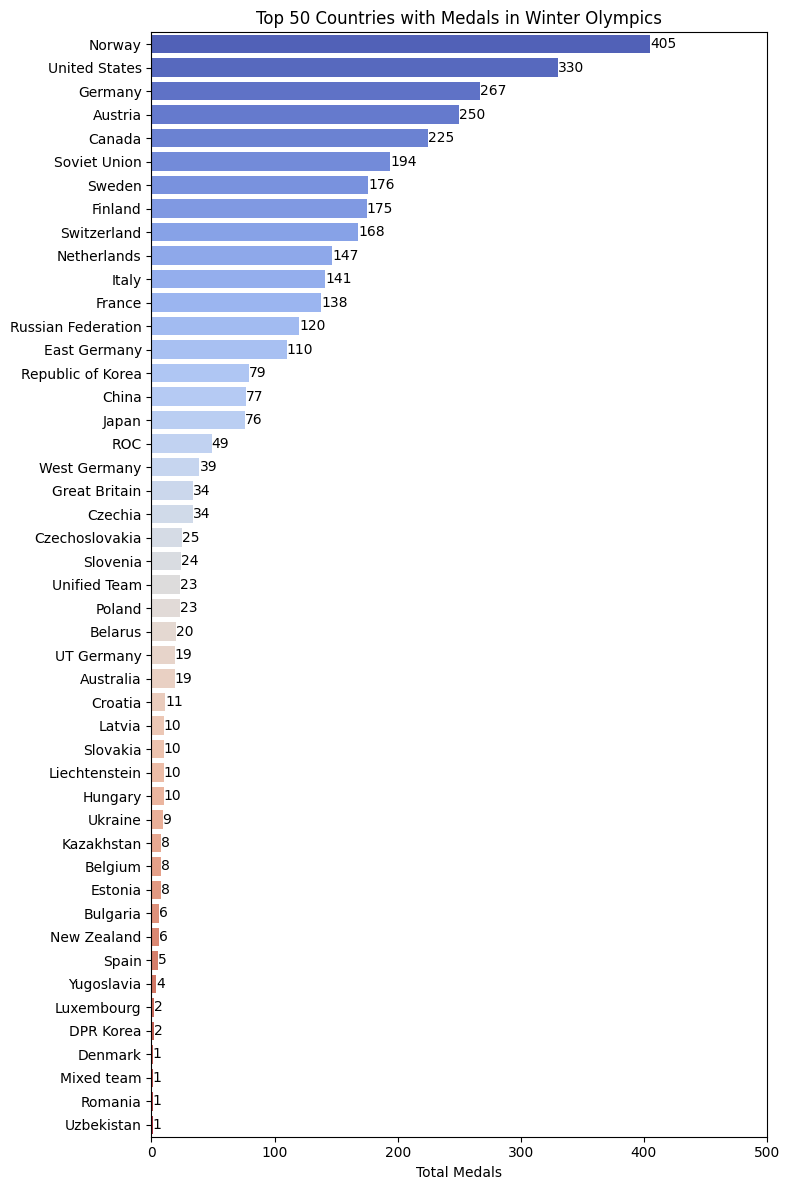

In [28]:
# Top 50 países das Olimpiadas Inverno
plt.figure(figsize=(8, 12))

ax = sns.barplot(x=df_winter_total.head(50)['total'],
            y=df_winter_total.head(50).index,
            orient='h',
            hue=df_winter_total.head(50).index,
            palette='coolwarm'
            )

for i in range(len(ax.containers)):
  ax.bar_label(ax.containers[i], color='black')

ax.set_xlabel('Total Medals')
ax.set_xlim(0, 500)
ax.set_ylabel("")
ax.set_title('Top 50 Countries with Medals in Winter Olympics')

plt.tight_layout()

plt.show()

## Medalhas - Total

In [24]:
# Obtendo o total
df_sw = df_final[df_final['edition'].isin(['Summer Olympics', 'Winter Olympics'])]

df_sw_total = (
    df_sw.groupby('country')[['gold', 'silver', 'bronze', 'total']]
    .sum()
    .sort_values('total', ascending=False))
df_sw_total.head(5)

,gold,silver,bronze,total
country,,,,
United States,1223,1007,881,3111
Soviet Union,473,376,355,1204
Great Britain,317,350,359,1026
Germany,327,324,328,979
France,288,325,362,975


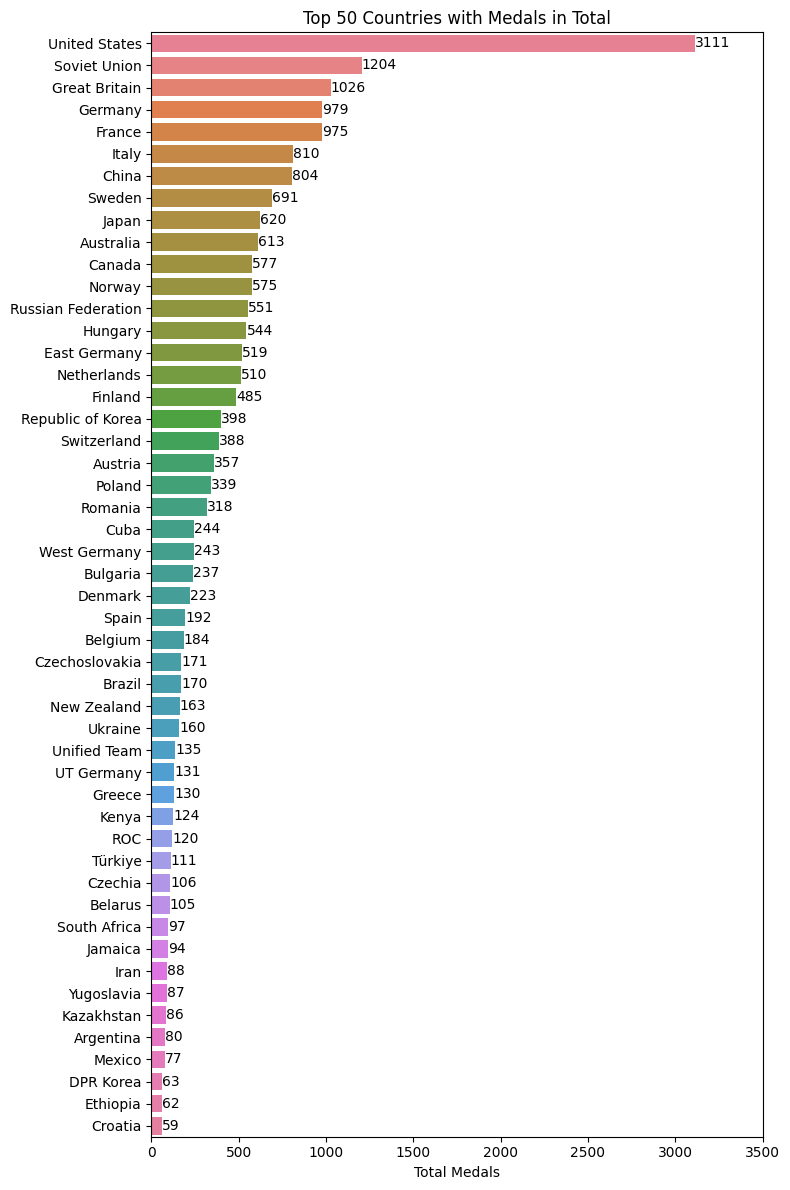

In [29]:
# Top 50 países das Olimpiadas Total de Medalhas
plt.figure(figsize=(8, 12))

ax = sns.barplot(x=df_sw_total.head(50)['total'],
            y=df_sw_total.head(50).index,
            orient='h',
            hue=df_sw_total.head(50).index,
            )

for i in range(len(ax.containers)):
  ax.bar_label(ax.containers[i], color='black')

ax.set_xlabel('Total Medals')
ax.set_xlim(0, 3500)
ax.set_ylabel("")
ax.set_title('Top 50 Countries with Medals in Total')

plt.tight_layout()

plt.show()